In [34]:
from sklearn.datasets import fetch_california_housing
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
import numpy as np
import matplotlib.pyplot as plt

In [25]:
x , y = fetch_california_housing(return_X_y=True)

In [26]:
print(x.shape)
print(y.shape)

(20640, 8)
(20640,)


In [27]:
k_model = KNeighborsRegressor()
k_model.fit(x , y)

KNeighborsRegressor()

In [28]:
l_model = LinearRegression()
l_model.fit(x , y)

LinearRegression()

In [29]:
k_model.predict(x)
l_model.predict(x)

array([4.13164983, 3.97660644, 3.67657094, ..., 0.17125141, 0.31910524,
       0.51580363])

In [44]:
pipe = Pipeline([
    ('scale',StandardScaler()),
    ('model',KNeighborsRegressor(n_neighbors=11))
])
pipe.get_params

<bound method Pipeline.get_params of Pipeline(steps=[('scale', StandardScaler()),
                ('model', KNeighborsRegressor(n_neighbors=11))])>

In [45]:
g_model = GridSearchCV(estimator = pipe , param_grid={'model__n_neighbors' : [1,2,3,4,5,6,7,8,9,10]} , cv=3)

In [46]:
g_model.fit(x,y)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('scale', StandardScaler()),
                                       ('model',
                                        KNeighborsRegressor(n_neighbors=11))]),
             param_grid={'model__n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]})

In [43]:
import pandas as pd
pd.DataFrame(g_model.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__n_neighbors,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,0.012000,0.000818,0.252669,0.019602,1,{'model__n_neighbors': 1},0.324068,0.334830,0.323371,0.327423,0.005245,10
1,0.012327,0.000471,0.284838,0.026450,2,{'model__n_neighbors': 2},0.468788,0.503457,0.424388,0.465544,0.032361,9
2,0.011642,0.000499,0.289034,0.022844,3,{'model__n_neighbors': 3},0.518547,0.543340,0.473595,0.511827,0.028867,8
3,0.012003,0.000004,0.300251,0.022179,4,{'model__n_neighbors': 4},0.540323,0.564974,0.499827,0.535041,0.026857,7
4,0.012000,0.000814,0.315021,0.022721,5,{'model__n_neighbors': 5},0.551149,0.579313,0.511781,0.547414,0.027696,6
5,0.011997,0.000009,0.324244,0.026181,6,{'model__n_neighbors': 6},0.558435,0.586185,0.521134,0.555251,0.026652,5
6,0.012326,0.000471,0.332740,0.023627,7,{'model__n_neighbors': 7},0.564207,0.590509,0.525223,0.559979,0.026820,4
7,0.011669,0.000474,0.341522,0.027556,8,{'model__n_neighbors': 8},0.568637,0.593942,0.529337,0.563972,0.026580,3
8,0.011647,0.000461,0.350751,0.024836,9,{'model__n_neighbors': 9},0.571972,0.594863,0.529928,0.565588,0.026891,2
9,0.011317,0.000486,0.355348,0.022090,10,{'model__n_neighbors': 10},0.573760,0.595831,0.532973,0.567522,0.026038,1


In [47]:
k_y_true = y[0:100]
k_y_pred = g_model.predict(x)[0:100]

l_y_true = y[0:100]
l_y_pred = l_model.predict(x)[0:100]

Text(0, 0.5, 'CAR PRICE')

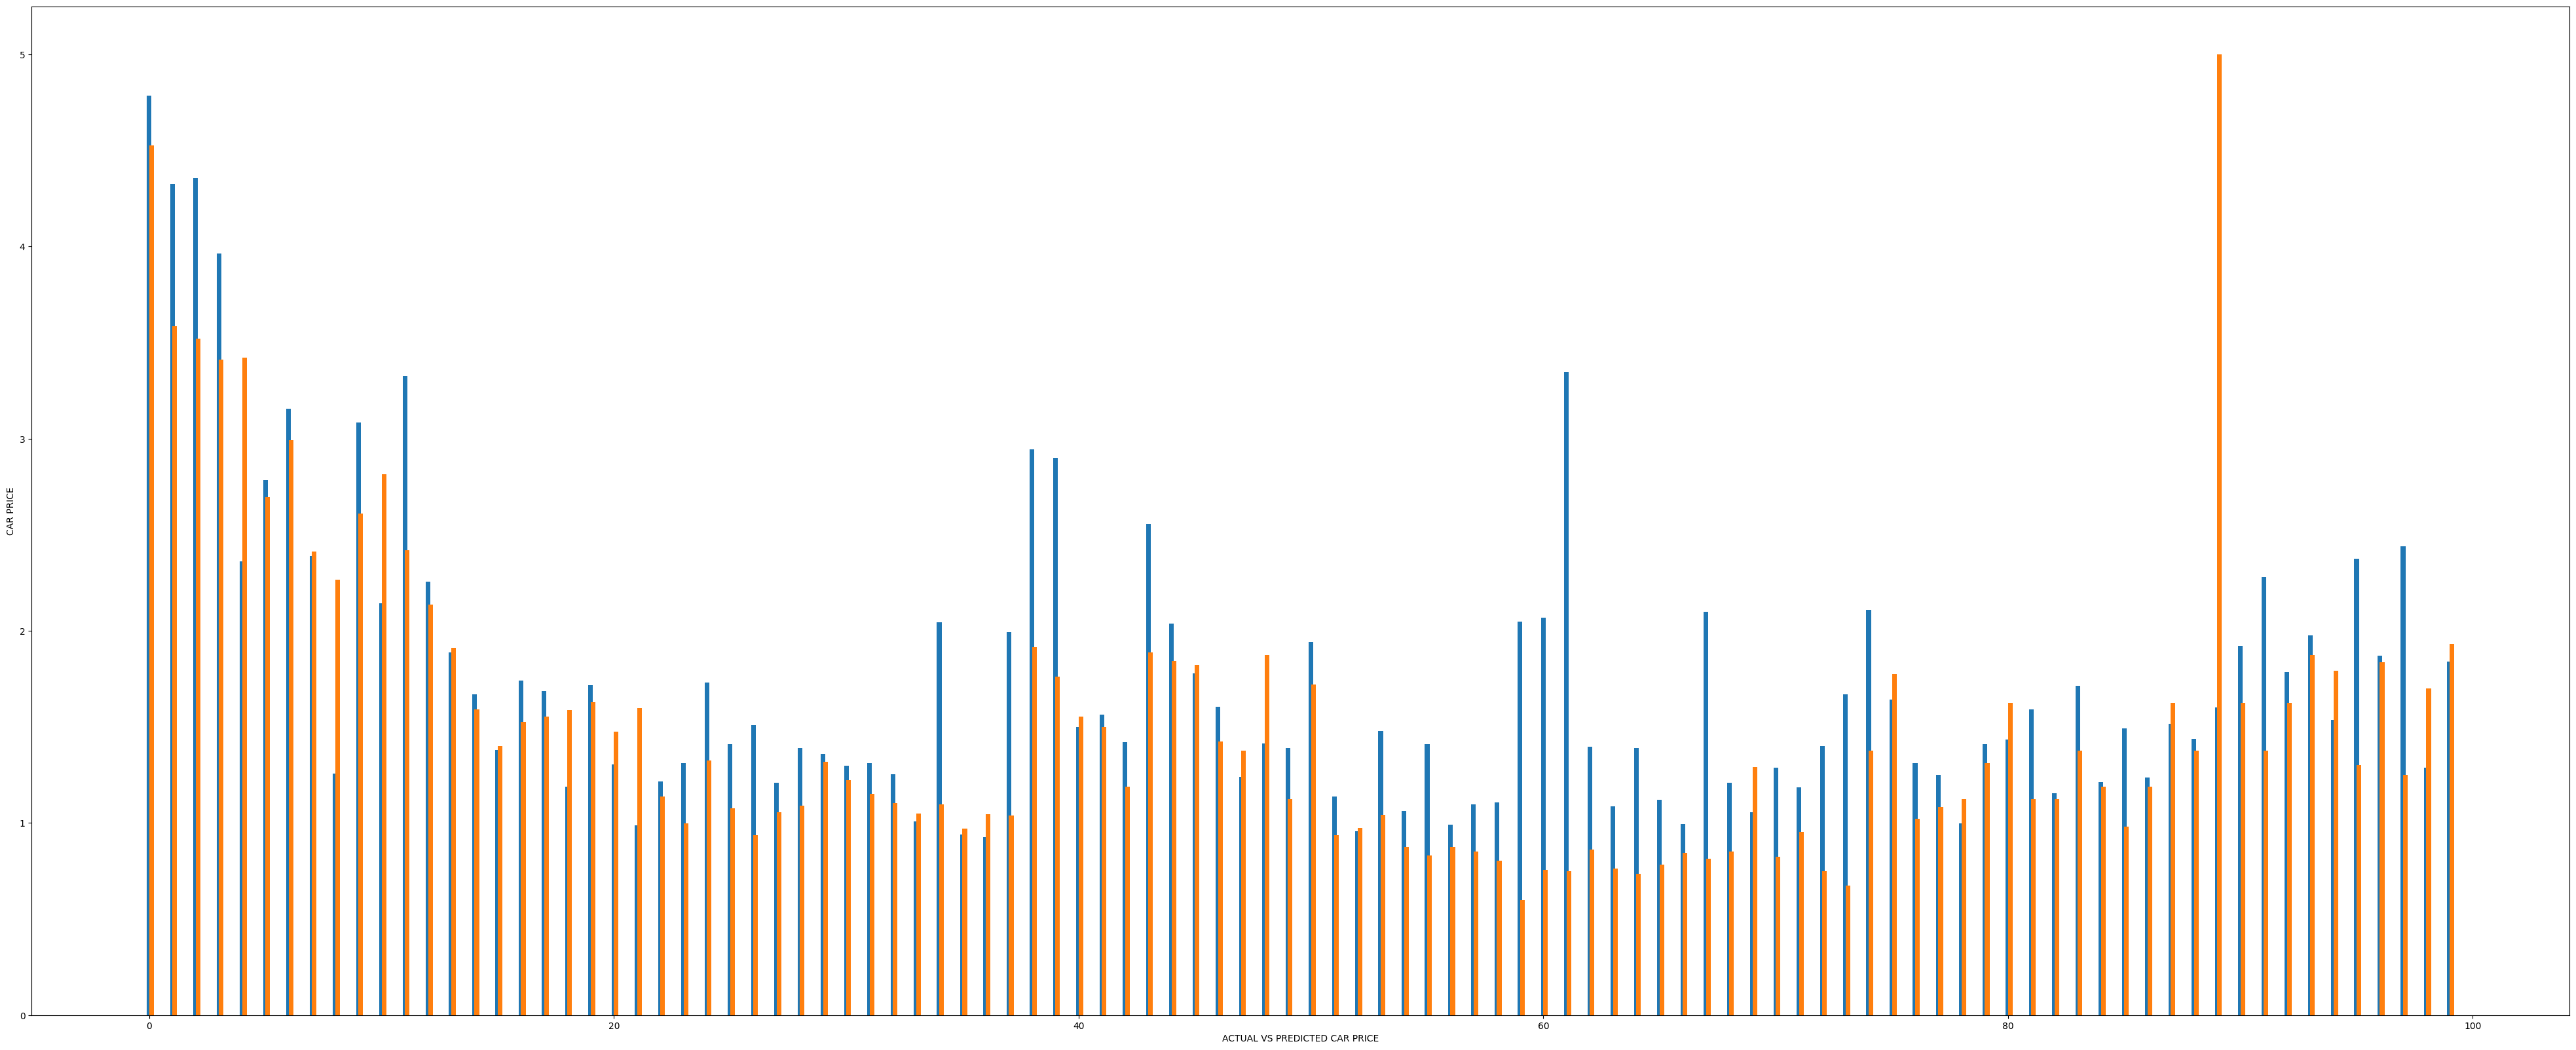

In [48]:
ind = np.arange(100)
plt.figure(figsize=(50,20))

width=0.1

plt.bar(ind , k_y_pred , 0.2 , label='PREDICTED CAR PRICE')
plt.bar(ind + width , k_y_true , 0.2 , label='ACTUAL CAR PRICE')

plt.xlabel('ACTUAL VS PREDICTED CAR PRICE')
plt.ylabel('CAR PRICE')

Text(0, 0.5, 'CAR PRICE')

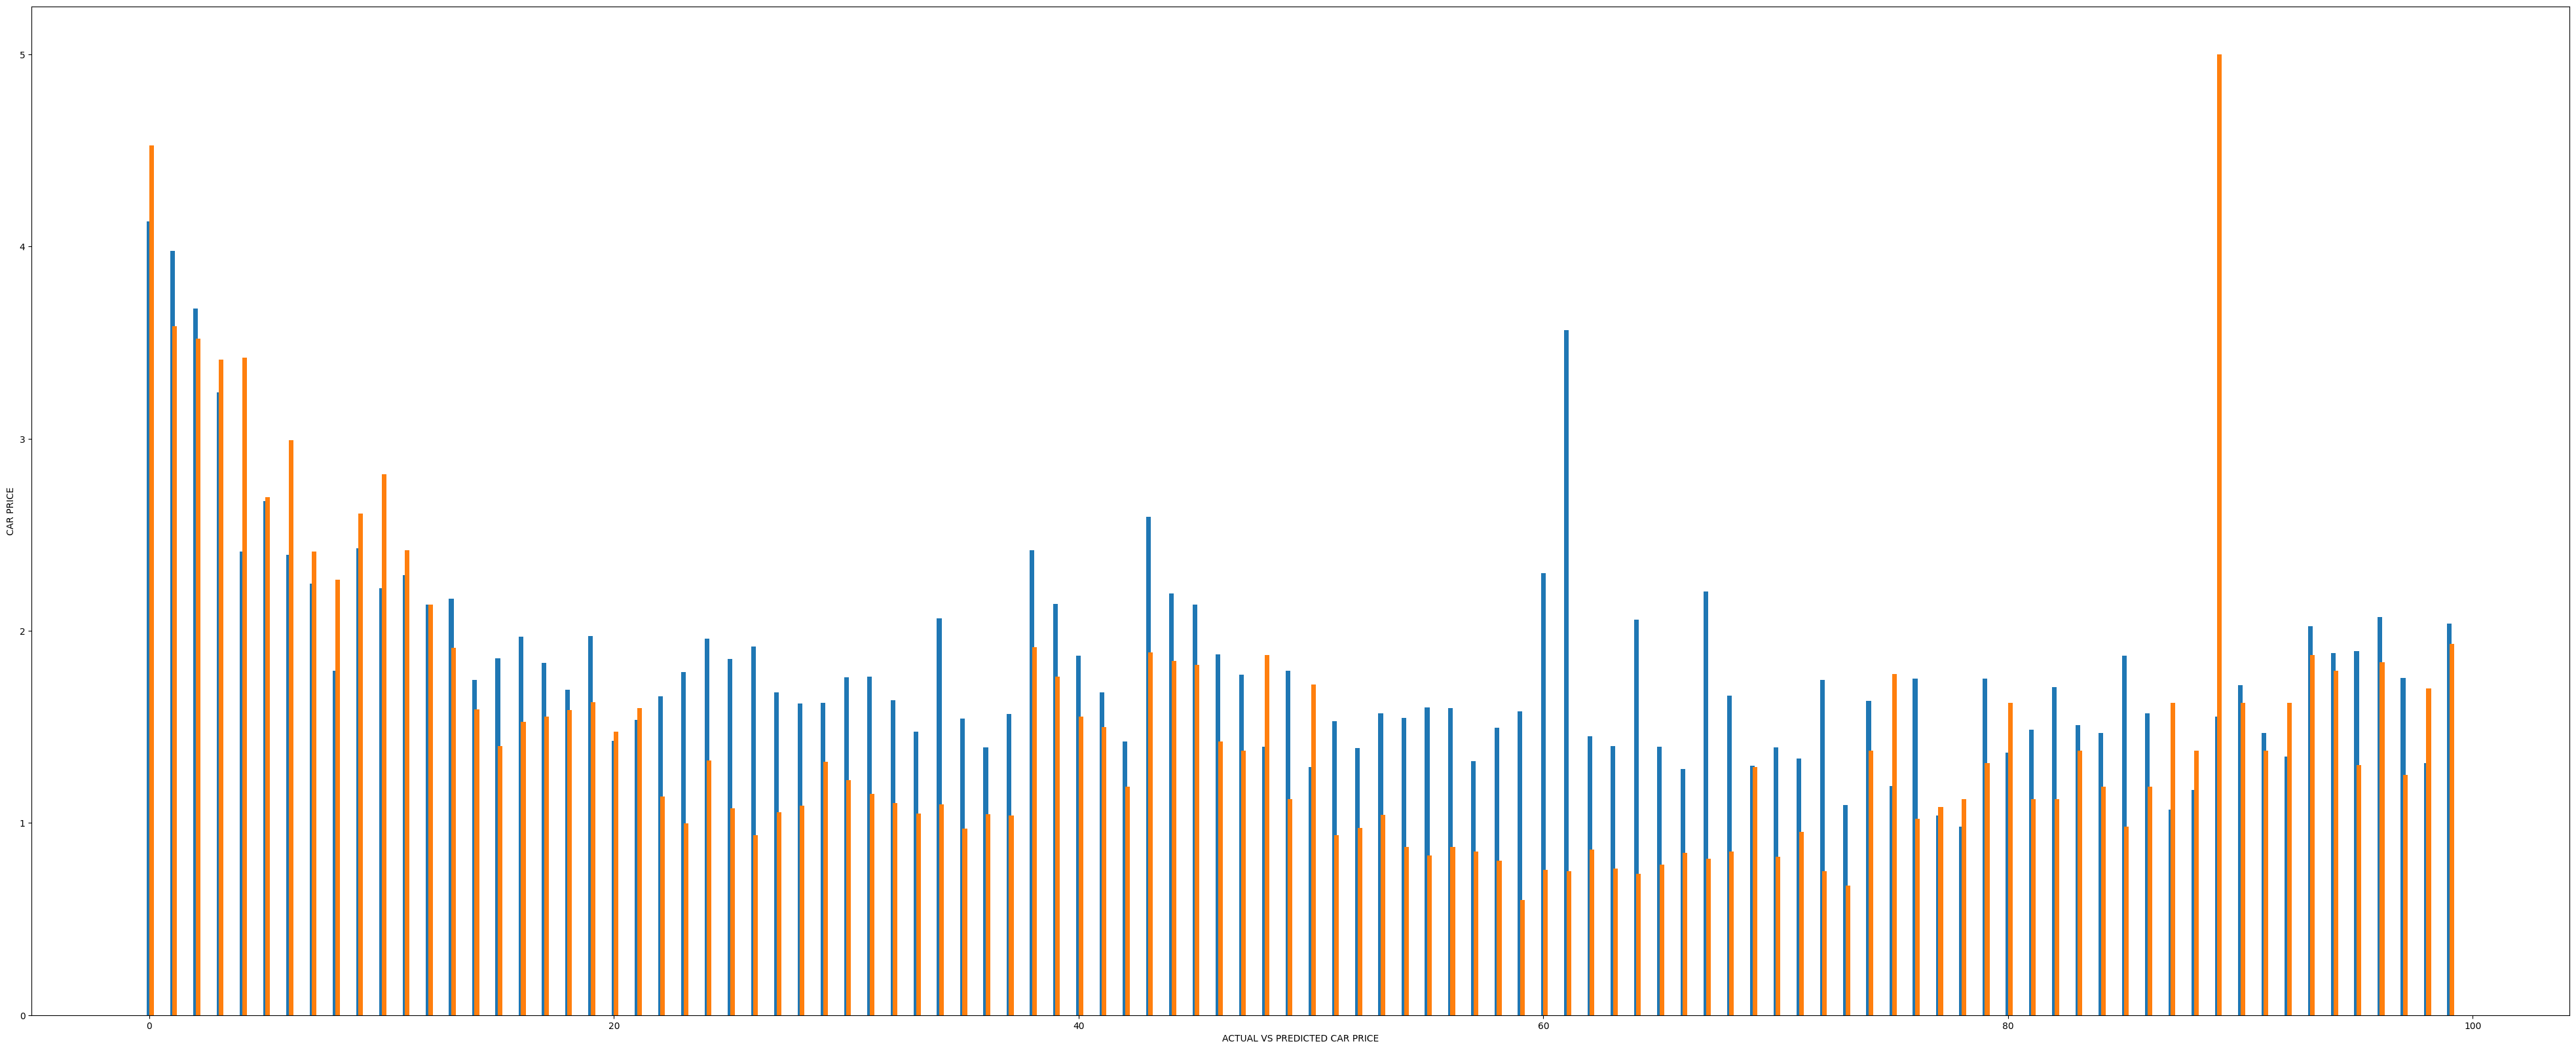

In [32]:
ind = np.arange(100)
plt.figure(figsize=(50,20))

width=0.1

plt.bar(ind , l_y_pred , 0.2 , label='PREDICTED CAR PRICE')
plt.bar(ind + width , l_y_true , 0.2 , label='ACTUAL CAR PRICE')

plt.xlabel('ACTUAL VS PREDICTED CAR PRICE')
plt.ylabel('CAR PRICE')

In [15]:
import pandas as pd
data = {'area':[2000,2568,2700,3200,3550,4000] , 'price' : [80000,110000,120000,200000,255000,330000]} 
df = pd.DataFrame(data)

In [16]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(df[['area']],df.price)

LinearRegression()

In [31]:
x = 3000
round(model.predict([[x]])[0],2)


c:\Users\ASWIN\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


182106.6

In [35]:
m = model.coef_[0]
c = model.intercept_
print(m)
print(c)

131.13242486836933
-211290.67187971307


In [36]:
# y = mx + c
y = round((m * x )+ c , 2)
y

182106.6

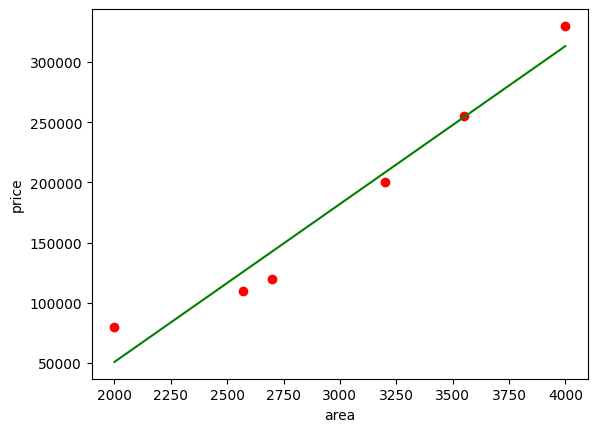

In [38]:
import matplotlib.pyplot as plt

plt.xlabel('area')
plt.ylabel('price')
plt.scatter(df.area,df.price,color='red',marker='o')
plt.plot(df.area,model.predict(df[['area']]),color='green')

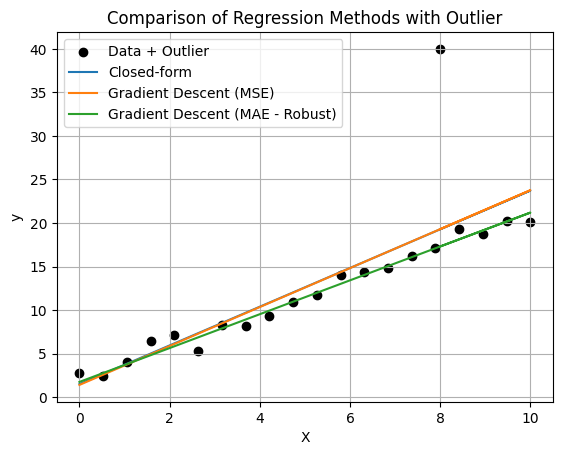

[ 1.48664704  2.65705203  3.82745702  4.99786201  6.168267    7.33867199
  8.50907698  9.67948197 10.84988696 12.02029195 13.19069694 14.36110193
 15.53150692 16.70191191 17.8723169  19.0427219  20.21312689 21.38353188
 22.55393687 23.72434186 19.27680289] 
 [ 1.39560206  2.57297314  3.75034423  4.92771532  6.1050864   7.28245749
  8.45982857  9.63719966 10.81457074 11.99194183 13.16931292 14.346684
 15.52405509 16.70142617 17.87879726 19.05616835 20.23353943 21.41091052
 22.5882816  23.76565269 19.29164256] 
 [ 1.74        2.76387548  3.78775096  4.81162643  5.83550191  6.85937739
  7.88325287  8.90712835  9.93100383 10.9548793  11.97875478 13.00263026
 14.02650574 15.05038122 16.07425669 17.09813217 18.12200765 19.14588313
 20.16975861 21.19363409 17.30290727]


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Generate simple data
np.random.seed(0)
X = np.linspace(0, 10, 20)
y = 2 * X + 1 + np.random.normal(0, 1, size=X.shape)

# Step 2: Add outlier
X_outlier = np.append(X, [8])
y_outlier = np.append(y, [40])  # Big outlier

# Helper function to plot
def plot_line(x, y, y_pred, label):
    plt.plot(x, y_pred, label=label)

# Step 3: Closed-form solution
X_mean = np.mean(X_outlier)
y_mean = np.mean(y_outlier)
a1 = (np.mean(X_outlier * y_outlier) - X_mean * y_mean) / (np.mean(X_outlier**2) - X_mean**2)
a0 = y_mean - a1 * X_mean
y_pred_closed = a0 + a1 * X_outlier

# Step 4: Gradient Descent with MSE
a0_gd = 0
a1_gd = 0
lr = 0.01
epochs = 1000

for _ in range(epochs):
    y_pred = a0_gd + a1_gd * X_outlier
    error = y_pred - y_outlier
    a0_gd -= lr * np.mean(error)
    a1_gd -= lr * np.mean(error * X_outlier)

y_pred_gd_mse = a0_gd + a1_gd * X_outlier

# Step 5: Gradient Descent with MAE (more robust)
a0_mae = 0
a1_mae = 0

for _ in range(epochs):
    y_pred = a0_mae + a1_mae * X_outlier
    error = y_pred - y_outlier
    grad_a0 = np.mean(np.sign(error))
    grad_a1 = np.mean(np.sign(error) * X_outlier)
    a0_mae -= lr * grad_a0
    a1_mae -= lr * grad_a1

y_pred_gd_mae = a0_mae + a1_mae * X_outlier

# Step 6: Plot all
plt.scatter(X_outlier, y_outlier, color='black', label='Data + Outlier')
plot_line(X_outlier, y_outlier, y_pred_closed, 'Closed-form')
plot_line(X_outlier, y_outlier, y_pred_gd_mse, 'Gradient Descent (MSE)')
plot_line(X_outlier, y_outlier, y_pred_gd_mae, 'Gradient Descent (MAE - Robust)')
plt.legend()
plt.title('Comparison of Regression Methods with Outlier')
plt.xlabel('X')
plt.ylabel('y')
plt.grid(True)
plt.show()

print(f'{y_pred_closed} \n {y_pred_gd_mse} \n {y_pred_gd_mae}')
